In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('cars_dataset.csv')
df.head()

,year,mileage_km,engine_volume,horsepower,owners_count,price_usd
0,2011,151498,2.1,150,4,7060.0
1,2024,73808,4.0,278,2,42600.0
2,2019,118414,1.1,60,3,9890.0
3,2015,138625,3.6,266,3,17840.0
4,2012,174184,2.7,194,4,8090.0


In [13]:
feature_cols = ['year', 'mileage_km', 'engine_volume', 'horsepower', 'owners_count'] #определение признаков
target_col = 'price_usd' #цена которую хотим предсказать
X = df[feature_cols].values
y = df[target_col].values.reshape(-1, 1)
print(f"x shape: {X.shape}, y shape: {y.shape}")

x shape: (500, 5), y shape: (500, 1)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} примеров, Test: {X_test.shape[0]} примеров")

Train: 400 примеров, Test: 100 примеров


In [17]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [18]:
class RegressionANN:
    def __init__(self, layer_sizes, lr=0.01):
        self.lr = lr
        self.weights = []
        self.biases = []
        
        for i in range(len(layer_sizes) - 1):
            w = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2 / layer_sizes[i])
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights.append(w)
            self.biases.append(b)
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return (x > 0).astype(float)
    
    def forward(self, X):
        self.activations = [X]
        self.z_values = []
        
        a = X
        for i in range(len(self.weights)):
            z = a @ self.weights[i] + self.biases[i]
            self.z_values.append(z)
            
            if i == len(self.weights) - 1:
                a = z
            else:
                a = self.relu(z)
            
            self.activations.append(a)
        
        return a
    
    def backward(self, X, y, output):
        m = X.shape[0]
        deltas = [output - y]
        
        for i in range(len(self.weights) - 1, 0, -1):
            delta = (deltas[-1] @ self.weights[i].T) * self.relu_derivative(self.activations[i])
            deltas.append(delta)
        
        deltas.reverse()
        
        for i in range(len(self.weights)):
            grad_w = self.activations[i].T @ deltas[i] / m
            grad_b = np.sum(deltas[i], axis=0, keepdims=True) / m
            self.weights[i] -= self.lr * grad_w
            self.biases[i] -= self.lr * grad_b
    
    def train(self, X, y, epochs=1000, verbose=True):
        losses = []
        for epoch in range(epochs):
            output = self.forward(X)
            loss = np.mean((output - y) ** 2)
            losses.append(loss)
            
            self.backward(X, y, output)
            
            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | MSE Loss: {loss:.4f}")
        
        return losses
    
    def predict(self, X):
        return self.forward(X)

In [19]:
np.random.seed(42)

model = RegressionANN(layer_sizes=[5, 16, 8, 1], lr=0.05)
losses = model.train(X_train_scaled, y_train_scaled, epochs=2000)

Epoch    0 | MSE Loss: 15.2127
Epoch  100 | MSE Loss: 0.0767
Epoch  200 | MSE Loss: 0.0506
Epoch  300 | MSE Loss: 0.0392
Epoch  400 | MSE Loss: 0.0331
Epoch  500 | MSE Loss: 0.0296
Epoch  600 | MSE Loss: 0.0274
Epoch  700 | MSE Loss: 0.0258
Epoch  800 | MSE Loss: 0.0246
Epoch  900 | MSE Loss: 0.0236
Epoch 1000 | MSE Loss: 0.0228
Epoch 1100 | MSE Loss: 0.0222
Epoch 1200 | MSE Loss: 0.0215
Epoch 1300 | MSE Loss: 0.0210
Epoch 1400 | MSE Loss: 0.0206
Epoch 1500 | MSE Loss: 0.0201
Epoch 1600 | MSE Loss: 0.0198
Epoch 1700 | MSE Loss: 0.0194
Epoch 1800 | MSE Loss: 0.0191
Epoch 1900 | MSE Loss: 0.0188


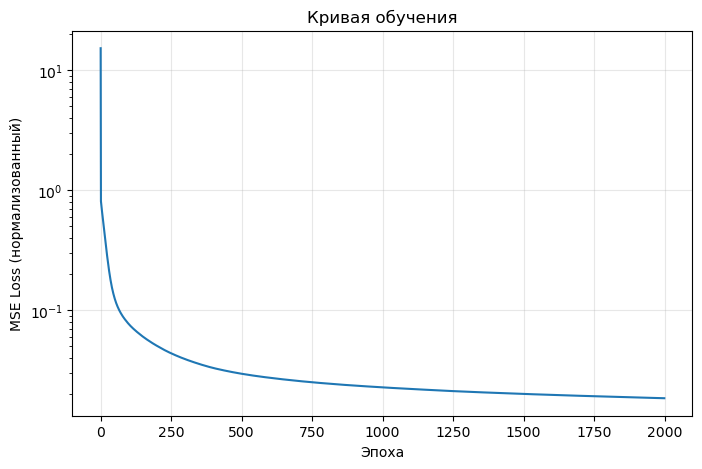

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss (нормализованный)')
plt.title('Кривая обучения')
plt.yscale('log')  # log-масштаб удобен, когда loss падает на порядки
plt.grid(alpha=0.3)
plt.show()

In [21]:
y_pred_scaled = model.predict(X_test_scaled)

# Денормализация
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test_scaled)

# Метрики в реальных долларах
mae = np.mean(np.abs(y_pred - y_test_real))
rmse = np.sqrt(np.mean((y_pred - y_test_real) ** 2))

print(f"MAE  (средняя ошибка): ${mae:,.0f}")
print(f"RMSE (с штрафом за большие ошибки): ${rmse:,.0f}")

MAE  (средняя ошибка): $1,256
RMSE (с штрафом за большие ошибки): $1,551


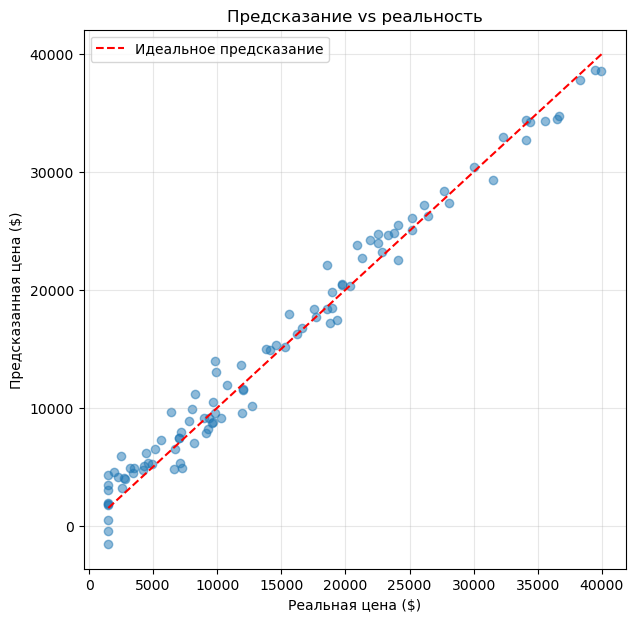

In [22]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test_real, y_pred, alpha=0.5)
plt.plot([y_test_real.min(), y_test_real.max()], 
         [y_test_real.min(), y_test_real.max()], 
         'r--', label='Идеальное предсказание')
plt.xlabel('Реальная цена ($)')
plt.ylabel('Предсказанная цена ($)')
plt.title('Предсказание vs реальность')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [27]:
new_car = np.array([0,0,0,0,0])
new_car[[0]] = int(input("Год выпуска: "))
new_car[[1]] = int(input("Пробег: "))
new_car[[2]] = float(input("Объем двигателя: "))
new_car[[3]] = int(input("Мощность л.с: "))
new_car[[4]] = int(input("Количество владельцев: "))
new_car_scaled = scaler_X.transform(new_car.reshape(1,-1))

pred_scaled = model.predict(new_car_scaled)
pred_price = scaler_y.inverse_transform(pred_scaled)

print(f"Предсказанная цена: ${pred_price[0][0]:,.0f}")

Год выпуска:  2000
Пробег:  180000
Объем двигателя:  3.0
Мощность л.с:  230
Количество владельцев:  7


Предсказанная цена: $439
